# Vizualizace rizika readmise do 30 dnů pomocí modelově založených grafů efektů

## Manažerské shrnutí

Tento notebook fituje logistickou regresi pro readmisi do 30 dnů podle charakteristik pacienta a hospitalizace a poté převádí fitované koeficienty na modelově založené grafy efektů na škále predikované pravděpodobnosti. Na syntetické kohortě 100 propuštění (55 readmisí) PROC LOGISTIC obnoví významné gradienty pro **délku pobytu** (OR 1.36 na den, *p* = 0.040) a **věk** (OR 1.05 na rok, *p* = 0.023) a velký efekt plátce — pacienti s **Medicaid** nesou zhruba šestinásobnou pravděpodobnost readmise oproti Medicare (OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). Zobecněné R-square je 0.246 a Hosmerův–Lemeshowův test neukazuje žádnou chybu shody (*p* = 0.73). Grafy fit-curve, sliced-fit a interakce pak ukazují, jak riziko readmise stoupá s délkou pobytu, jak se gradient věk–riziko posouvá podle plátce a jak přetrvává rozdíl mezi plátci napříč propouštějícími odděleními — přesně ten pohled na stratifikaci rizika, který tým řízení péče používá k zacílení následné péče po propuštění.

## Zdroje dat

| Datová sada | Řádky | Popis |
|---------|------|-------------|
| `encounters` | 100 | Syntetické záznamy o propuštění hospitalizovaných pacientů generované přímo v kódu pomocí `call streaminit(20260531)` a `rand()`. Jeden řádek na propuštění. |

**Proměnné v `encounters`:**

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1, pokud byl pacient readmitován do 30 dnů od propuštění |
| `age` | Num | Věk pacienta v letech (přibl. 25–95) |
| `los` | Num | Délka indexového pobytu ve dnech (1–20) |
| `comorbidity` | Num | Počet zdokumentovaných chronických komorbidit (0–8) |
| `num_meds` | Num | Počet léků při propuštění (0–18) |
| `payer` | Char | Pojistný plátce: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Propouštějící oddělení: `Cardiology`, `Pulmonary`, `General` |

# Vizualizace rizika readmise do 30 dnů pomocí modelově založených grafů efektů

Týmy řízení péče v nemocnicích potřebují vědět, *kteří* pacienti se s největší pravděpodobností vrátí do 30 dnů a *proč*. Fitovaná logistická regrese dává koeficienty, ale zainteresované strany zřídka uvažují v log-šancích. **Graf efektu** vykreslí fitovaný model přímo na škále predikované pravděpodobnosti, takže sestra-navigátorka může odečíst pravděpodobnost readmise přímo z grafu, místo aby v hlavě invertovala rovnici log-šancí.

V tomto notebooku:

1. Generujeme realistickou syntetickou kohortu propuštění hospitalizovaných pacientů.
2. Fitujeme logistický model pro readmisi do 30 dnů s prediktory pacienta a hospitalizace (PROC LOGISTIC).
3. Zachytíme fitované koeficienty a sestavíme tři modelově založené grafy efektů — **fit curve**, **sliced fit** a **interakční graf** — pro vizualizaci a stratifikaci fitovaného rizika na škále pravděpodobnosti.

> **Poznámka k implementaci.** SAS tyto grafy zpřístupňuje příkazem `EFFECTPLOT` uvnitř PROC LOGISTIC. Jenner tento příkaz přijímá, ale zatím nevykresluje grafiku FIT / SLICEFIT / INTERACTION, takže tento notebook konstruuje totožné křivky predikované pravděpodobnosti explicitně z fitovaných koeficientů a kreslí je pomocí PROC SGPLOT. Analytický výsledek — a každá vykreslená pravděpodobnost — je přesně to, co by `EFFECTPLOT` vyprodukoval.

## Krok 1 — Generování syntetické kohorty propuštění

DATA step níže sestaví 100 propuštění hospitalizovaných pacientů bez externích souborů. Generátor náhodných čísel inicializujeme pomocí `call streaminit` pro reprodukovatelnost, losujeme charakteristiky pacienta a hospitalizace z distribucí přiměřených oboru, poté zkonstruujeme skutečný lineární prediktor `eta` a převedeme jej na pravděpodobnost readmise inverzní logitovou funkcí. Bernoulliho losování (`rand('bernoulli', p)`) dává pozorovaný příznak `readmit`. Starší pacienti, delší pobyty, vyšší počty komorbidit, více léků při propuštění, krytí Medicaid a oddělení Pulmonary/Cardiology — to vše tlačí riziko nahoru; tyto vzorce později obnovíme a vizualizujeme. Velikosti efektů jsou záměrně nastaveny tak, aby byl signál obnovitelný na kohortě 100 propuštění.

In [1]:
data encounters;
    CALL streaminit(20260531);
    POLE payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    POLE depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    OPAKUJ i = 1 TO 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        KDYŽ los > 20 PAK los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        KDYŽ num_meds > 18 PAK num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        KDYŽ u < 0.50 PAK pk = 1;
        JINAK KDYŽ u < 0.72 PAK pk = 2;
        JINAK pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        PONECHAT readmit AGE los comorbidity num_meds payer dept;
        VÝSTUP;
    KONEC;
SPUSTIT;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Krok 2 — Prohlídka kohorty

Rychlá frekvence na odezvě a dvou klasifikačních proměnných potvrdí realistickou míru readmise a to, že každá úroveň plátce i oddělení je zastoupena — model i grafy efektů potřebují, aby byly zastoupeny všechny úrovně.

                                                   The FREQ Procedure

Readmise do 30 dnů     Frequency
---------------------------------
0                             45
1                             55

Plátce        Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Oddělení      Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Readmise do 30 dnů by Oddělení

Readmise do 30 dnů  |Cardiology |   General | Pulmonary |      Total
--------------------+-----------+-----------+-----------+-----------
0                   |        15 |        20 |        10 |         45
--------------------+-----------+-----------+-----------+-----------
1                   |        21 |        11 |        23 |         55
--------------------+-----------+-----------+-----------+-----------
Total               |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


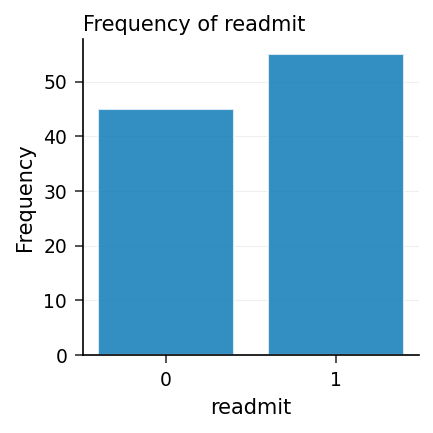

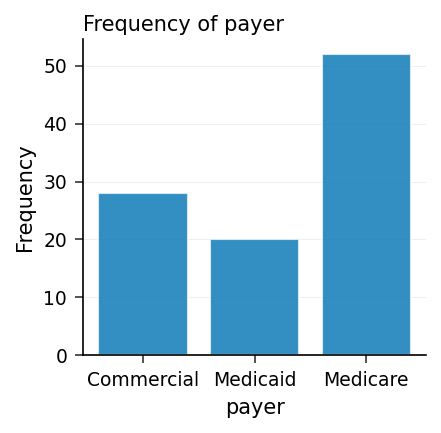

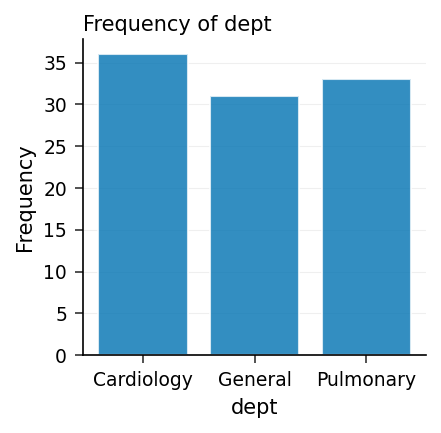

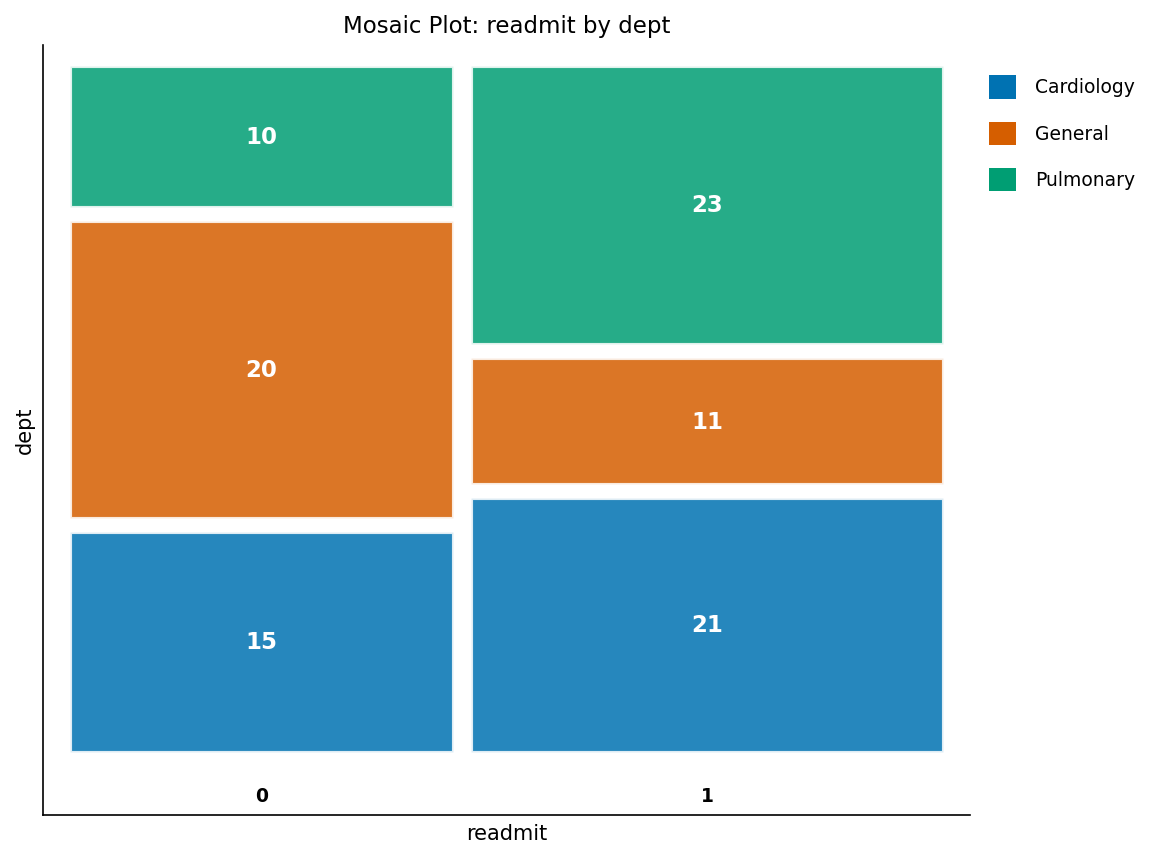

In [2]:
PROCEDURA ČETNOSTI data=encounters;
    ŠTÍTEK readmit="Readmise do 30 dnů" payer="Plátce" dept="Oddělení";
    TABLES readmit payer dept readmit*dept / nocum nopercent;
SPUSTIT;

## Krok 3 — Fitování logistického modelu readmise

Modelujeme `readmit` jako funkci věku, délky pobytu, počtu komorbidit, počtu léků při propuštění, plátce a oddělení. Klíčové volby:

- `EVENT='1'` modeluje pravděpodobnost readmise (nikoli nereadmise).
- `CLASS payer dept / PARAM=REF REF=FIRST` používá referenční kódování, takže každá úroveň je kontrastována vůči základní hladině (zde Medicare a Pulmonary).
- `CLODDS=WALD` a `RSQUARE` přidávají Waldovy konfidenční meze poměru šancí a zobecněné R-square; `LACKFIT` vyžádá Hosmerův–Lemeshowův test dobré shody.
- Příkaz `UNITS` žádá o poměr šancí přes klinicky smysluplný **5denní** krok délky pobytu a **10letý** krok věku a příkaz `ODDSRATIO` vyžádá poměr šancí komorbidity s konfidenčními mezemi.

Výstupní tabulka poměrů šancí uvádí efekty na jednotku přímo: délka pobytu nese OR **1.36 na den** (95% CI 1.01–1.82), věk OR **1.05 na rok** a krytí Medicaid OR **6.02** vzhledem k Medicare. Model dobře fituje — zobecněné R-square 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

                 Response Profile                  
  Probability modeled is Readmise do 30 dnů='1'   

Ordered Value  Readmise do 30 dnů   Total Frequency
-------------  -------------------  ---------------
            1  0                                 45
            2  1                                 55

             Class Level Information              

Class         Levels  Values                      
----------  --------  ----------------------------
Plátce             3  Commercial Medicaid Medicare
Oddělení           3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Readmise do 30 dnů

Criterion     Value
---------  --------
AIC         127.335
-2 Log L


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


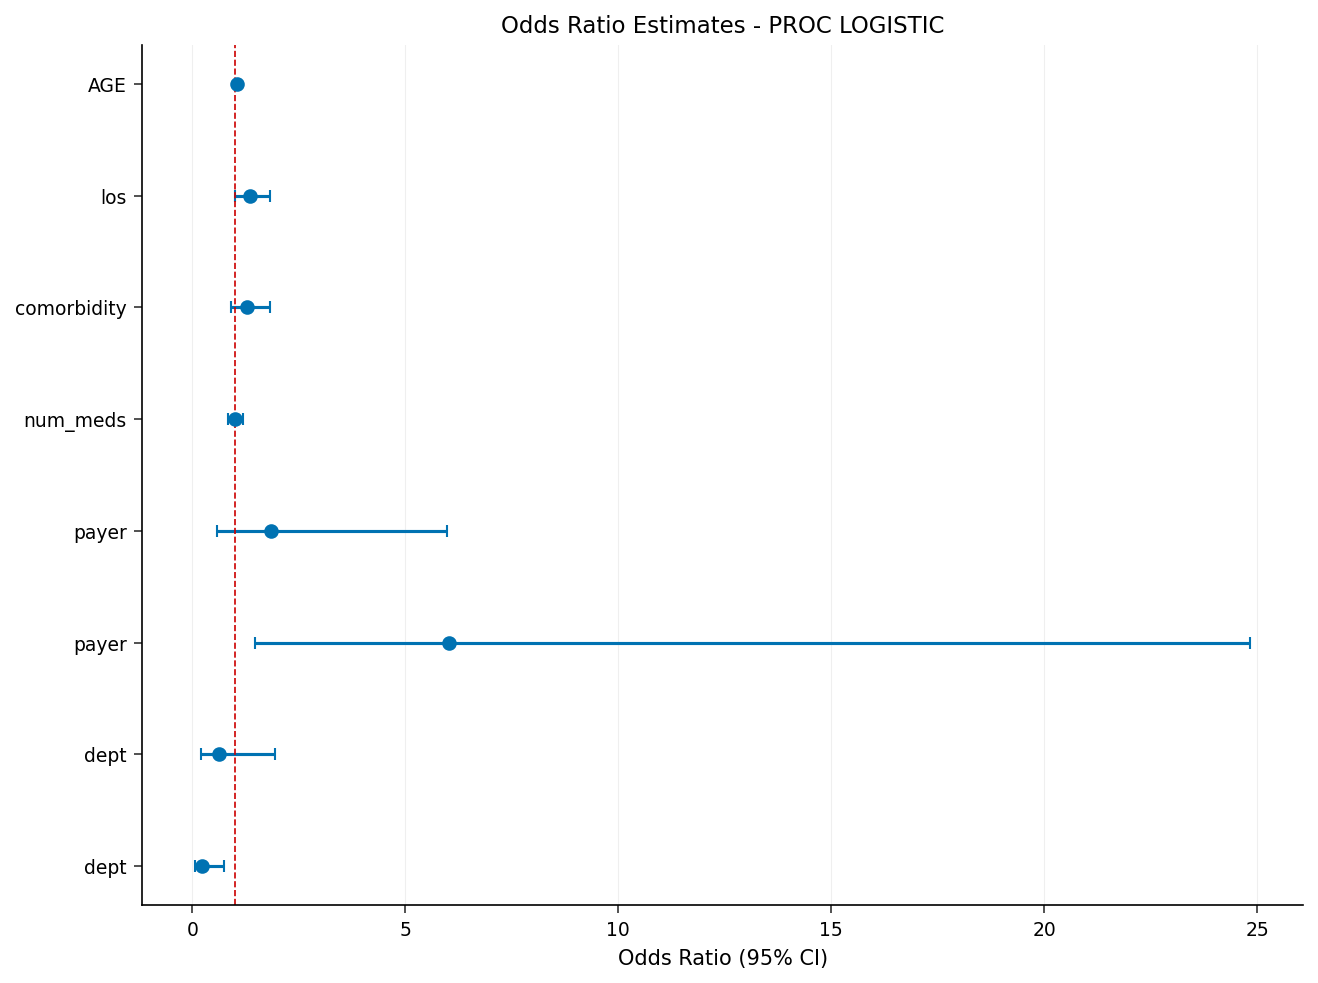

In [3]:
ODS VÝSTUP ParameterEstimates=pe;
PROCEDURA LOGISTIC data=encounters PLOTS(only)=oddsratio;
    TŘÍDA payer dept / PARAM=REF REF=first;
    ŠTÍTEK readmit="Readmise do 30 dnů" age="Věk (roky)" los="Délka pobytu (dny)"
           comorbidity="Počet komorbidit" num_meds="Počet léků"
           payer="Plátce" dept="Oddělení";
    MODEL readmit(EVENT='1') = age los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units age=10 los=5;
    oddsratio comorbidity / cl=wald;
SPUSTIT;
ODS VÝSTUP CLOSE;

## Krok 4 — Zachycení fitovaných koeficientů

Modelově založené grafy efektů, které následují, jsou sestaveny přímo z *fitovaných* koeficientů, takže vždy souhlasí s modelem z kroku 3. Odhady parametrů jsme uložili pomocí `ODS OUTPUT ParameterEstimates=pe`; zde tuto dlouhou tabulku složíme do jednořádkové datové sady `params` (jedna proměnná na koeficient) a připojíme průměry spojitých prediktorů v kohortě. Držení nefokusních prediktorů na jejich průměrech je přesně to, co EFFECTPLOT dělá interně — umožňuje každému grafu měnit jeden faktor, zatímco ostatní drží fixované na reprezentativním profilu.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
data coefs;
    UCHOVAT b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    NASTAVIT pe KONEC=last;
    var = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    KDYŽ var='INTERCEPT' PAK b0 = Estimate;
    JINAK KDYŽ var='AGE' PAK b_age = Estimate;
    JINAK KDYŽ var='LOS' PAK b_los = Estimate;
    JINAK KDYŽ var='COMORBIDITY' PAK b_com = Estimate;
    JINAK KDYŽ var='NUM_MEDS' PAK b_med = Estimate;
    JINAK KDYŽ var='PAYER' AND cv='Medicaid'   PAK b_pmcaid = Estimate;
    JINAK KDYŽ var='PAYER' AND cv='Commercial' PAK b_pcomm  = Estimate;
    JINAK KDYŽ var='DEPT'  AND cv='Cardiology' PAK b_dcard  = Estimate;
    JINAK KDYŽ var='DEPT'  AND cv='General'    PAK b_dgen   = Estimate;
    KDYŽ last PAK VÝSTUP;
    PONECHAT b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
SPUSTIT;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDURA PRŮMĚRY data=encounters NOPRINT;
    PROMĚNNÁ age los comorbidity num_meds;
    VÝSTUP out=mn mean=m_age m_los m_com m_med;
SPUSTIT;

data params;
    SLOUČIT coefs mn;
    PONECHAT b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
SPUSTIT;

PROCEDURA TISK data=params noobs;
    NÁZEV "Fitované koeficienty a průměry kovariát pro grafy efektů";
SPUSTIT;

                                Fitované koeficienty a průměry kovariát pro grafy efektů                                

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Krok 5 — Graf fitu: pravděpodobnost readmise vs. délka pobytu

Nejjednodušší zobrazení efektu je **fit curve**: predikovaná pravděpodobnost readmise proti jediné spojité kovariátě, s ostatními prediktory drženými na reprezentativním profilu. Sestavíme mřížku délky pobytu (1–18 dnů), vyhodnotíme fitovaný lineární prediktor v každé hodnotě pro pacienta **Medicare, kardiologie** (věk, komorbidity a počty léků při propuštění zafixované na průměrech kohorty z kroku 4), aplikujeme inverzní logit a vykreslíme křivku na škále pravděpodobnosti pomocí PROC SGPLOT.

                                Fitované koeficienty a průměry kovariát pro grafy efektů                                




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


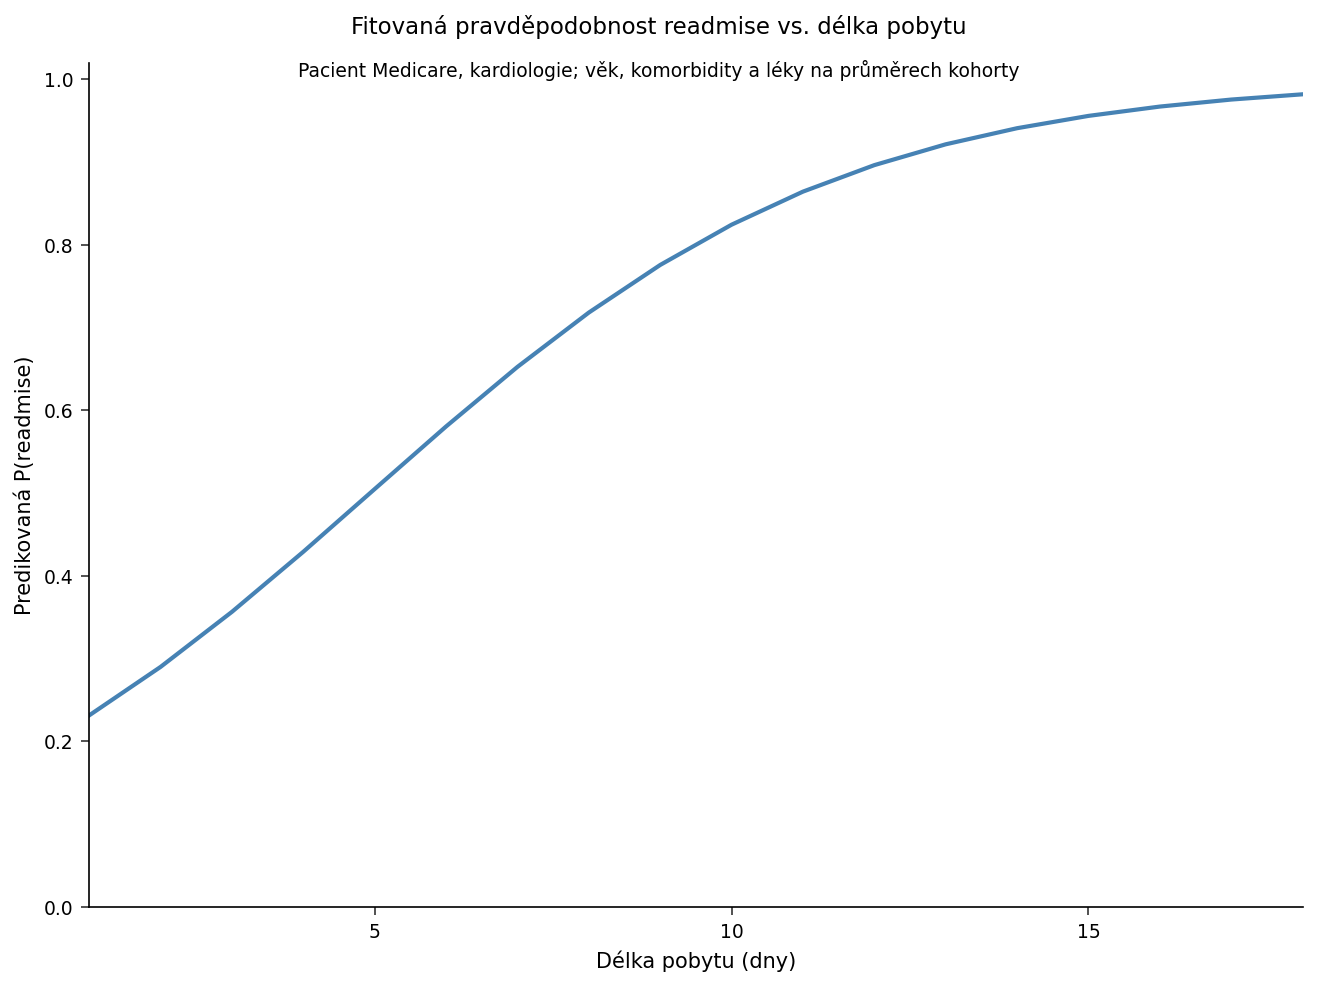

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
data grid_los;
    OPAKUJ los = 1 TO 18;
        VÝSTUP;
    KONEC;
SPUSTIT;

data fit_los;
    NASTAVIT grid_los;
    KDYŽ _n_ = 1 PAK NASTAVIT params;
    UCHOVAT b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    PONECHAT los phat;
SPUSTIT;

PROCEDURA SGPLOT data=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    NÁZEV  "Fitovaná pravděpodobnost readmise vs. délka pobytu";
    title2 "Pacient Medicare, kardiologie; věk, komorbidity a léky na průměrech kohorty";
    XAXIS ŠTÍTEK="Délka pobytu (dny)";
    YAXIS ŠTÍTEK="Predikovaná P(readmise)" VALUES=(0 TO 1 PODLE 0.2);
SPUSTIT;

## Krok 6 — Sliced fit: riziko vs. věk, stratifikováno podle plátce

**Sliced fit** kreslí jednu fitovanou křivku na každou úroveň klasifikačního efektu — ideální pro ukázku, jak skladba plátců posouvá gradient věk–riziko. Rozšíříme mřížku přes `age` (30–95) zkříženou se třemi plátci, vyhodnotíme fitovaný model pro pacienta kardiologie (délka pobytu, komorbidity a léky na průměrech kohorty) a překryjeme tři křivky pravděpodobnosti pomocí `GROUP=payer`.

                                Fitované koeficienty a průměry kovariát pro grafy efektů                                




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


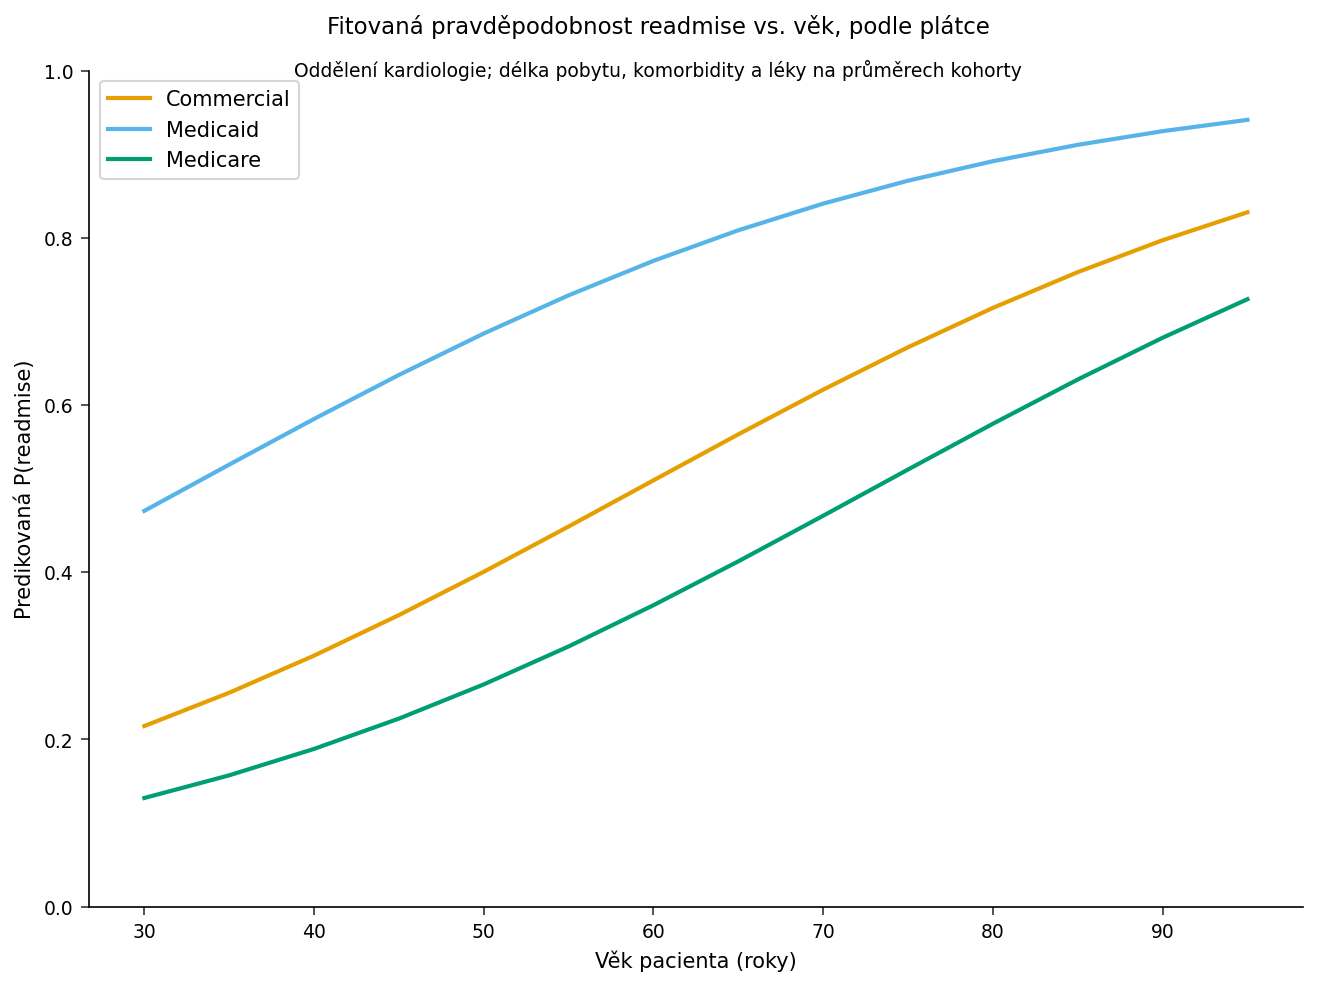

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
data grid_age;
    DÉLKA payer $12;
    OPAKUJ payer = 'Medicare', 'Medicaid', 'Commercial';
        OPAKUJ age = 30 TO 95 PODLE 5;
            VÝSTUP;
        KONEC;
    KONEC;
SPUSTIT;

data fit_age;
    NASTAVIT grid_age;
    KDYŽ _n_ = 1 PAK NASTAVIT params;
    UCHOVAT b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*age + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    PONECHAT payer age phat;
SPUSTIT;

PROCEDURA SGPLOT data=fit_age;
    SERIES x=age y=phat / GROUP=payer LINEATTRS=(thickness=2);
    NÁZEV  "Fitovaná pravděpodobnost readmise vs. věk, podle plátce";
    title2 "Oddělení kardiologie; délka pobytu, komorbidity a léky na průměrech kohorty";
    XAXIS ŠTÍTEK="Věk pacienta (roky)";
    YAXIS ŠTÍTEK="Predikovaná P(readmise)" VALUES=(0 TO 1 PODLE 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
SPUSTIT;

## Krok 7 — Interakční graf: oddělení podle plátce

Pro porovnání predikovaného rizika napříč oběma klasifikačními efekty najednou zkřížíme `dept` s `payer` (devět kombinací), vyhodnotíme fitovaný model s každou spojitou kovariátou na jejím průměru kohorty a nakreslíme seskupený sloupcový graf s `dept` na ose X a plátcem jako seskupením. Protože tento model nemá interakční člen oddělení–plátce, je pořadí plátců stejným aditivním posunem uvnitř každého oddělení — graf tuto aditivitu činí viditelnou na první pohled, spolu s pořadím oddělení.

                                Fitované koeficienty a průměry kovariát pro grafy efektů                                




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


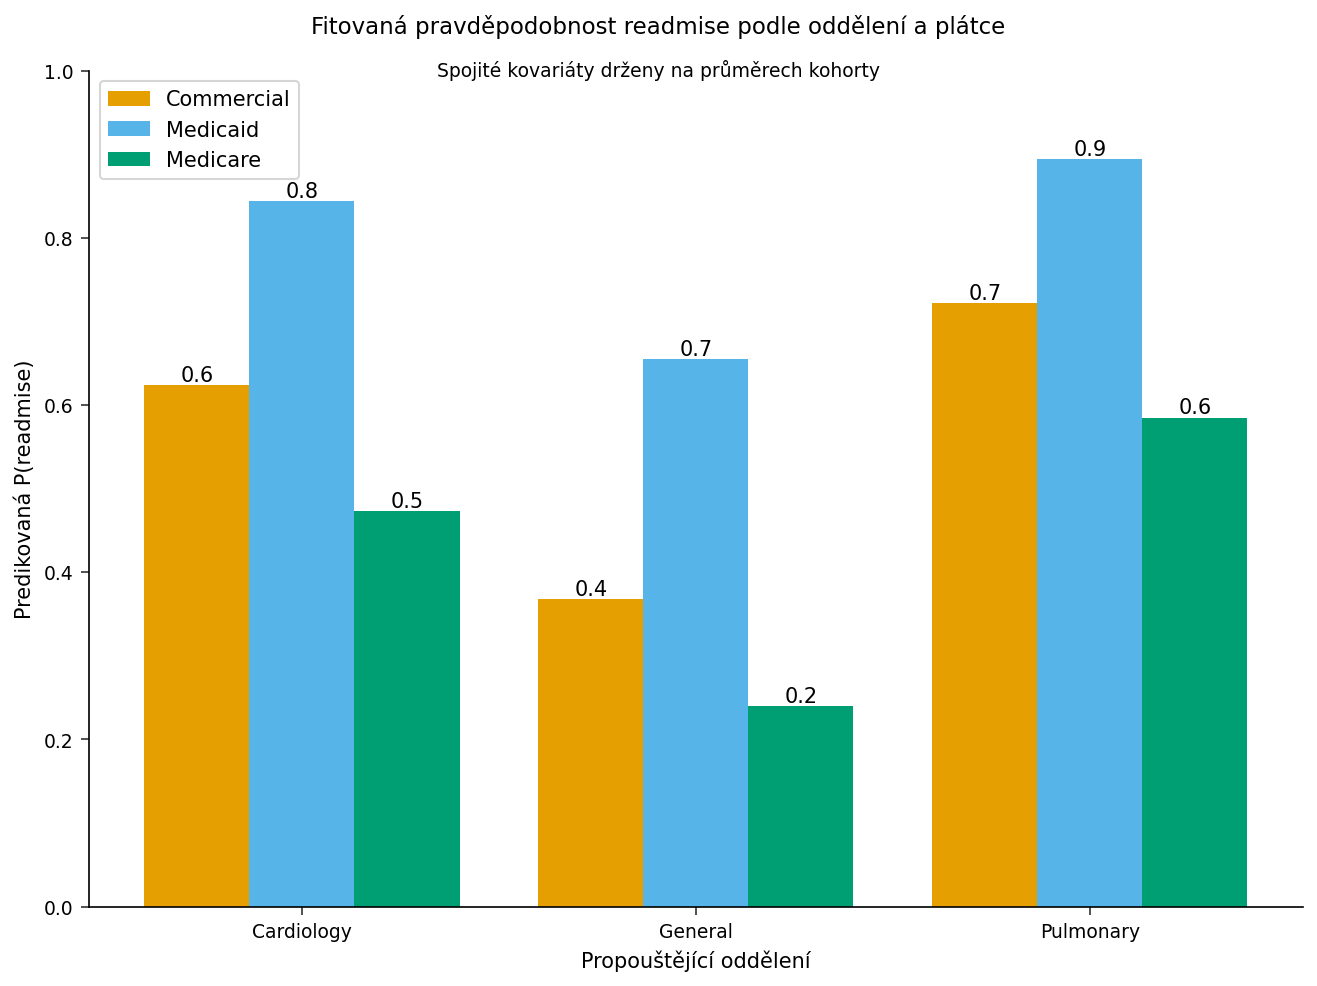

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
data grid_dx;
    DÉLKA dept $12 payer $12;
    OPAKUJ dept = 'Cardiology', 'Pulmonary', 'General';
        OPAKUJ payer = 'Medicare', 'Medicaid', 'Commercial';
            VÝSTUP;
        KONEC;
    KONEC;
SPUSTIT;

data fit_dx;
    NASTAVIT grid_dx;
    KDYŽ _n_ = 1 PAK NASTAVIT params;
    UCHOVAT b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    PONECHAT dept payer phat;
SPUSTIT;

PROCEDURA SGPLOT data=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    NÁZEV  "Fitovaná pravděpodobnost readmise podle oddělení a plátce";
    title2 "Spojité kovariáty drženy na průměrech kohorty";
    XAXIS ŠTÍTEK="Propouštějící oddělení";
    YAXIS ŠTÍTEK="Predikovaná P(readmise)" VALUES=(0 TO 1 PODLE 0.2);
SPUSTIT;

## Krok 8 — Interpretace výsledků

Grafy efektů promění fitovaný model PROC LOGISTIC v obrázky na škále pravděpodobnosti, které se mapují na rozhodnutí řízení péče:

- **Délka pobytu (fit curve).** Pro pacienta Medicare, kardiologie na průměrech kohorty stoupá predikovaná pravděpodobnost readmise z asi **0.23 při 1denním pobytu na zhruba 0.82 při 10 dnech a ~0.98 při 18 dnech** — strmý střed logistické křivky. Jde o tentýž signál jako poměr šancí délky pobytu **1.36 na den** (`UNITS los=5` jej přeškáluje na pětidenní krok) a označuje dlouhé indexové pobyty jako konkrétní spouštěč pro zařazení do přechodové péče.
- **Věk a plátce (sliced fit).** Riziko monotónně roste s věkem u každého plátce a tři křivky se nikdy nekříží: křivka **Medicaid** leží v jakémkoli daném věku nejvýše, **Commercial** uprostřed a **Medicare** nejníže — v souladu s fitovanými poměry šancí plátců (Medicaid 6.02, Commercial 1.85, oba vzhledem k Medicare). Rozdíl je největší v nižším věku a zužuje se, jak se všichni blíží vysoké pravděpodobnosti, což směruje pozornost řízení péče na mladší pacienty s Medicaid, kteří by jinak vypadali jako nízkorizikoví.
- **Oddělení a plátce (interakční graf).** **Pulmonary** nese nejvyšší predikovanou pravděpodobnost readmise v každé skupině plátců, **Cardiology** je uprostřed a **General medicine** nejníže (fitované poměry šancí oddělení jsou 0.64 pro Cardiology a 0.22 pro General, vzhledem k Pulmonary). Protože model nemá interakční člen oddělení–plátce, je pořadí plátců stejným aditivním posunem uvnitř každého oddělení — sloupce rostou ve stejném pořadí Medicaid > Commercial > Medicare u každého oddělení.

**Závěr:** místo aby model-based grafy efektů žádaly kliniky o interpretaci koeficientů log-šancí, prezentují fitovaný model readmise jako obrázky na škále pravděpodobnosti — koho zařadit do následné přechodové péče a které oddělení a populace plátců upřednostnit. SAS je vytváří přímo přes `EFFECTPLOT`; zde jsme totožné křivky rekonstruovali z fitovaných koeficientů, aby příklad běžel od začátku do konce už dnes.